#                            **                                        Ensemble Learning - Assignment (Practical)**

Q21  Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create a Bagging Classifier with Decision Trees as base estimator
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=2)

# Train the model
bagging_clf.fit(X_train, y_train)

# Make predictions
y_pred = bagging_clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.93


Q22 Train a Bagging Regressor using Decision Trees and evaluate using Mean
     Squared Error (MSE)

In [ ]:
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

# Generate synthetic dataset
# np.random.seed(42)
# X = np.linspace(-3, 3, 100).reshape(-1, 1)
# y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])
# Load dataset
data = load_diabetes()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Bagging Regressor with Decision Trees
bagging_regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=50,
    random_state=42
)
bagging_regressor.fit(X_train, y_train)

# Predictions and MSE Evaluation
y_pred = bagging_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (Bagging Regressor): {mse:.4f}")



Mean Squared Error (Bagging Regressor): 2939.6764


 Q23 Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=2)
clf.fit(X_train, y_train)

# Get feature importance scores
feature_importances = clf.feature_importances_

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({'Feature': data.feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print feature importance scores
print(feature_importance_df)


                    Feature  Importance
20             worst radius    0.177420
23               worst area    0.114107
27     worst concave points    0.094444
22          worst perimeter    0.091237
7       mean concave points    0.085142
3                 mean area    0.071301
13               area error    0.054421
0               mean radius    0.046738
2            mean perimeter    0.038826
6            mean concavity    0.028447
26          worst concavity    0.027901
21            worst texture    0.018817
10             radius error    0.017237
5          mean compactness    0.016303
1              mean texture    0.014251
12          perimeter error    0.012110
25        worst compactness    0.012049
24         worst smoothness    0.011541
29  worst fractal dimension    0.010423
28           worst symmetry    0.009182
16          concavity error    0.008022
4           mean smoothness    0.006371
11            texture error    0.006234
17     concave points error    0.005960


Q24 Train a Random Forest Regressor and compare its performance with a single Decision Tree

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

dt_predictions = dt_regressor.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

# Train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=2)
rf_regressor.fit(X_train, y_train)

rf_predictions = rf_regressor.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

# Print performance comparison
print("Decision Tree Performance:")
print(f"MSE: {dt_mse:.4f}, R²: {dt_r2:.4f}")

print("\nRandom Forest Performance:")
print(f"MSE: {rf_mse:.4f}, R²: {rf_r2:.4f}")



Decision Tree Performance:
MSE: 0.5561, R²: 0.5872

Random Forest Performance:
MSE: 0.2584, R²: 0.8082


Q25  Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split data (keeping all data for training since OOB will be used for validation)
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)

# Train model
rf.fit(X, y)

# Print OOB Score
print(f"OOB Score: {rf.oob_score_:.4f}")

OOB Score: 0.9533


Q26  Train a Bagging Classifier using SVM as a base estimator and print accuracy

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create Bagging Classifier with SVM as base estimator
base_estimator = SVC(probability=True)  # Using probability=True to allow Bagging to work with SVM
bagging_clf = BaggingClassifier(estimator=base_estimator, n_estimators=10, random_state=42)

# Train the model
bagging_clf.fit(X_train, y_train)

# Make predictions
y_pred = bagging_clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.97


Q27 Train a Random Forest Classifier with different numbers of trees and compare accuracy

Number of Trees: 1, Accuracy: 0.8860
Number of Trees: 10, Accuracy: 0.9035
Number of Trees: 20, Accuracy: 0.8947
Number of Trees: 50, Accuracy: 0.9123
Number of Trees: 200, Accuracy: 0.9211
Number of Trees: 400, Accuracy: 0.9386


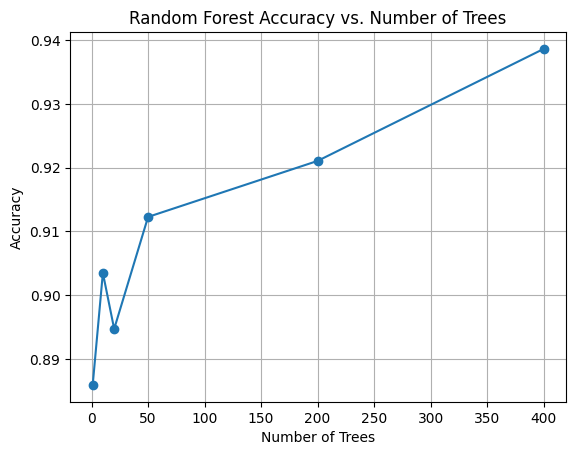

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Different numbers of trees to test
tree_counts = [1, 10, 20, 50, 200, 400]
accuracies = []

# Train and evaluate models
for n_trees in tree_counts:
    clf = RandomForestClassifier(n_estimators=n_trees, random_state=4)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Number of Trees: {n_trees}, Accuracy: {acc:.4f}")

# Plot results
plt.plot(tree_counts, accuracies, marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.grid()
plt.show()


Q28 Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score

# Generate synthetic dataset
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=4)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a Bagging Classifier with Logistic Regression as base estimator
base_estimator = LogisticRegression()
bagging_clf = BaggingClassifier(estimator=base_estimator, n_estimators=50, random_state=4)

# Train the model
bagging_clf.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = bagging_clf.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.9681


Q29  Train a Random Forest Regressor and analyze feature importance scores

Mean Squared Error: 5540.1246
     Feature  Importance
4  Feature 4    0.374249
8  Feature 8    0.143492
7  Feature 7    0.100991
9  Feature 9    0.099205
3  Feature 3    0.095746
6  Feature 6    0.091682
0  Feature 0    0.033159
1  Feature 1    0.028443
5  Feature 5    0.017662
2  Feature 2    0.015370


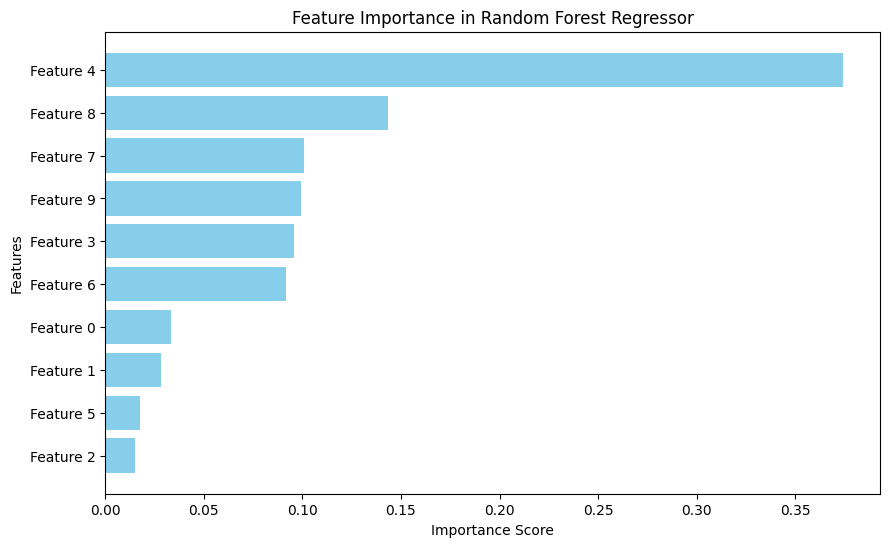

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# For reproducibility
np.random.seed(4)
from sklearn.datasets import make_regression

# Generate synthetic regression dataset
X, y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=4)

# Convert to DataFrame for better visualization
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Initialize and train the model
rf = RandomForestRegressor(n_estimators=100, random_state=4)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Compute Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# Extract feature importance scores
feature_importances = rf.feature_importances_

# Convert to DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display importance scores
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Regressor')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

Q30  Train an ensemble model using both Bagging and Random Forest and compare accuracy

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train Bagging Classifier
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=2)
bagging_clf.fit(X_train, y_train)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=50, random_state=2)
rf_clf.fit(X_train, y_train)

# Predictions
bagging_pred = bagging_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)

# Accuracy Comparison
bagging_acc = accuracy_score(y_test, bagging_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Bagging Accuracy: {bagging_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")


Bagging Accuracy: 0.9386
Random Forest Accuracy: 0.9474


Q31 Train a Random Forest Classifier and tune hyperparameters using GridSearchCV

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset (Example: Iris dataset)
data = load_iris()
X, y = data.data, data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Define the Random Forest Classifier
rf = RandomForestClassifier(random_state=5)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Train the model using GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Test Accuracy: 0.9333333333333333


Q32 Train a Bagging Regressor with different numbers of base estimators and compare performance

BaggingRegressor with 1 estimators - MSE: 0.5489
BaggingRegressor with 5 estimators - MSE: 0.3179
BaggingRegressor with 10 estimators - MSE: 0.2803
BaggingRegressor with 20 estimators - MSE: 0.2591
BaggingRegressor with 50 estimators - MSE: 0.2519
BaggingRegressor with 100 estimators - MSE: 0.2473


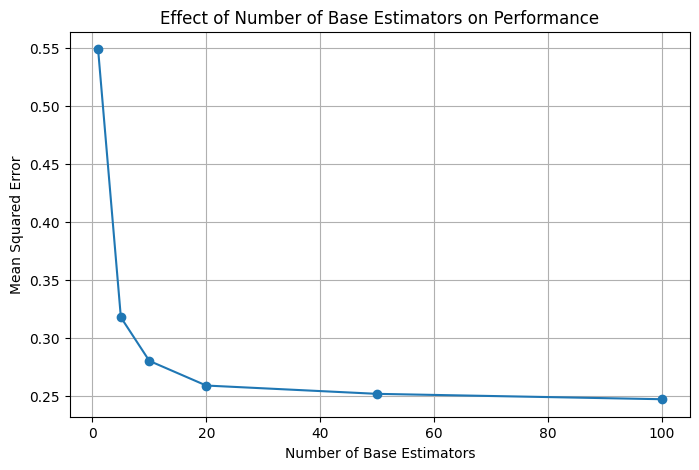

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Define different numbers of base estimators
n_estimators_list = [1, 5, 10, 20, 50, 100]
mse_scores = []

# Train and evaluate models
for n in n_estimators_list:
    model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=n, random_state=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f'BaggingRegressor with {n} estimators - MSE: {mse:.4f}')

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, mse_scores, marker='o', linestyle='-')
plt.xlabel('Number of Base Estimators')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Number of Base Estimators on Performance')
plt.grid()
plt.show()


Q33 Train a Random Forest Classifier and analyze misclassified samples

Accuracy: 0.94
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91        40
           1       0.96      0.95      0.95        74

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

Misclassified Samples:
Sample Index: 13, True Label: 1, Predicted Label: 0
Sample Index: 23, True Label: 1, Predicted Label: 0
Sample Index: 45, True Label: 1, Predicted Label: 0
Sample Index: 47, True Label: 0, Predicted Label: 1
Sample Index: 57, True Label: 1, Predicted Label: 0
Sample Index: 84, True Label: 0, Predicted Label: 1
Sample Index: 101, True Label: 0, Predicted Label: 1


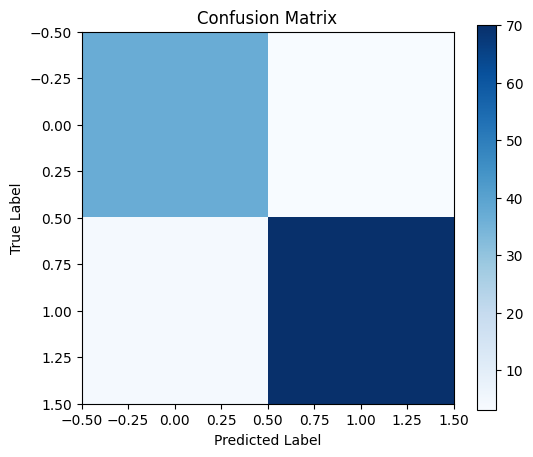

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer

# Load dataset (using Iris dataset as an example)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['target']), df['target'], test_size=0.2, random_state=3
)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=3)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:\n', classification_report(y_test, y_pred))

# Analyze misclassified samples
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_samples = X_test.iloc[misclassified_indices]
misclassified_labels = y_test.iloc[misclassified_indices]
misclassified_preds = y_pred[misclassified_indices]

print("Misclassified Samples:")
for i, index in enumerate(misclassified_indices):
    print(f"Sample Index: {index}, True Label: {misclassified_labels.iloc[i]}, Predicted Label: {misclassified_preds[i]}")

# Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Q34 Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

# Train a single Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Train a Bagging Classifier with Decision Trees as base learners
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=3
)
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_test)
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

# Print accuracy scores
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Bagging Classifier Accuracy: {bagging_accuracy:.4f}")


Decision Tree Accuracy: 0.8947
Bagging Classifier Accuracy: 0.9386


Q35 Train a Random Forest Classifier and visualize the confusion matrix

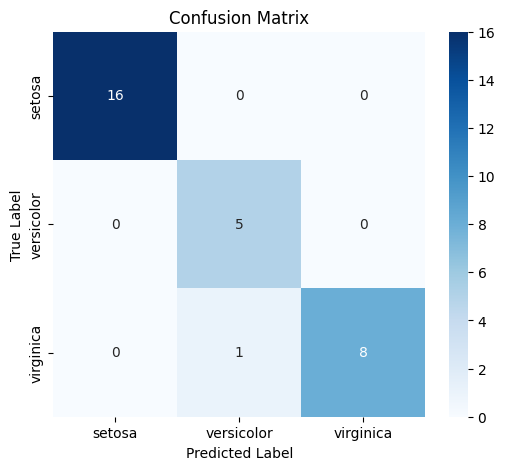

Accuracy: 0.97


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=20, random_state=4)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

 Q36 Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Define base models
base_models = [
    ('decision_tree', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]

# Define meta model
meta_model = LogisticRegression()

# Create Stacking Classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Train the model
stacking_clf.fit(X_train, y_train)

# Predict on test data
y_pred = stacking_clf.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Stacking Classifier Accuracy: {accuracy:.4f}")

# Train and evaluate individual models
for name, model in base_models + [('logistic_regression', meta_model)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

Stacking Classifier Accuracy: 0.9667
decision_tree Accuracy: 0.9333
svm Accuracy: 0.9667
logistic_regression Accuracy: 0.9667


Q37  Train a Random Forest Classifier and print the top 5 most important features

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=2)
rf.fit(X, y)

# Get feature importance
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Print top 5 features
print(feature_importances.head(5))

                 Feature  Importance
20          worst radius    0.154410
23            worst area    0.128149
27  worst concave points    0.118846
7    mean concave points    0.097132
22       worst perimeter    0.078753


Q38  Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score

In [11]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import precision_score, recall_score, f1_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create a Bagging Classifier with Decision Tree as base estimator
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10, random_state=2)

# Train the model
bagging_clf.fit(X_train, y_train)

# Predict on test data
y_pred = bagging_clf.predict(X_test)

# Evaluate performance
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print results
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Precision: 0.94
Recall: 0.94
F1-score: 0.94


Q39  Train a Random Forest Classifier and analyze the effect of max_depth on accuracy

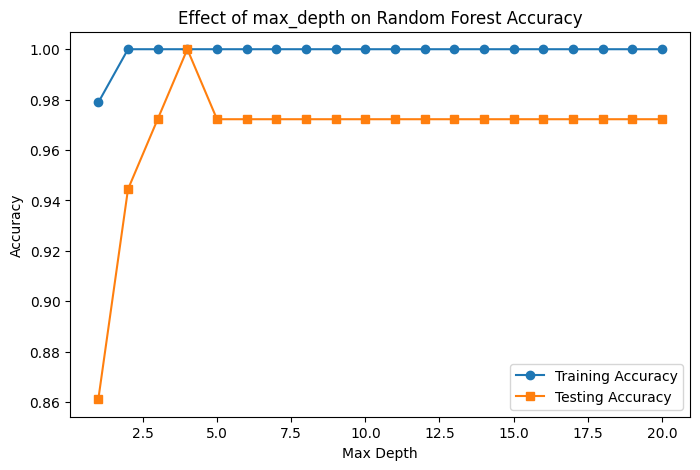

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Vary max_depth and track accuracy
max_depths = range(1, 21)
train_accuracies = []
test_accuracies = []

for depth in max_depths:
    model = RandomForestClassifier(max_depth=depth, random_state=5)
    model.fit(X_train, y_train)

    # Evaluate on training data
    train_preds = model.predict(X_train)
    train_accuracies.append(accuracy_score(y_train, train_preds))

    # Evaluate on test data
    test_preds = model.predict(X_test)
    test_accuracies.append(accuracy_score(y_test, test_preds))

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(max_depths, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(max_depths, test_accuracies, label='Testing Accuracy', marker='s')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest Accuracy')
plt.legend()
plt.show()


Q40 Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance

Performance Comparison:
Bagging with Decision Tree - MSE: 655.23, R²: 0.92
Bagging with KNN - MSE: 501.28, R²: 0.94


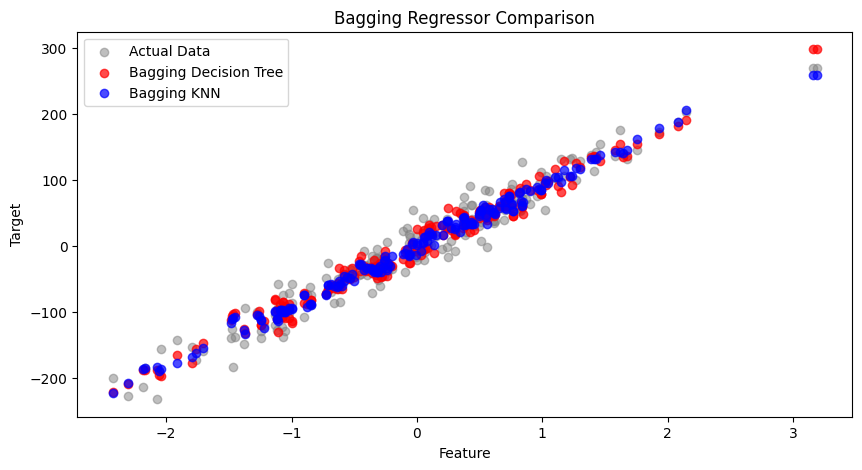

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

# Generate synthetic dataset
X, y = make_regression(n_samples=1000, n_features=1, noise=20, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Define base estimators
dt_regressor = DecisionTreeRegressor()
knn_regressor = KNeighborsRegressor()

# Train Bagging Regressors
bagging_dt = BaggingRegressor(estimator=dt_regressor, n_estimators=50, random_state=2)
bagging_knn = BaggingRegressor(estimator=knn_regressor, n_estimators=50, random_state=2)

bagging_dt.fit(X_train, y_train)
bagging_knn.fit(X_train, y_train)

# Predictions
y_pred_dt = bagging_dt.predict(X_test)
y_pred_knn = bagging_knn.predict(X_test)

# Evaluate performance
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("Performance Comparison:")
print(f"Bagging with Decision Tree - MSE: {mse_dt:.2f}, R²: {r2_dt:.2f}")
print(f"Bagging with KNN - MSE: {mse_knn:.2f}, R²: {r2_knn:.2f}")

# Plot results
plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual Data')
plt.scatter(X_test, y_pred_dt, color='red', alpha=0.7, label='Bagging Decision Tree')
plt.scatter(X_test, y_pred_knn, color='blue', alpha=0.7, label='Bagging KNN')
plt.legend()
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Bagging Regressor Comparison')
plt.show()


Q41  Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=4)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=4)
rf_classifier.fit(X_train, y_train)

# Predict probabilities
y_prob = rf_classifier.predict_proba(X_test)[:, 1]  # Probability of the positive class

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.9735


Q42 Train a Bagging Classifier and evaluate its performance using cross-validation

In [24]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score

# Load dataset
data = load_wine()
X, y = data.data, data.target

# Define base estimator
base_estimator = DecisionTreeClassifier()

# Define Bagging Classifier
bagging_clf = BaggingClassifier(estimator=base_estimator, n_estimators=20, random_state=1)

# Perform cross-validation (using accuracy as the scoring metric)
cv_scores = cross_val_score(bagging_clf, X, y, cv=5, scoring='accuracy')

# Print cross-validation results
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")

Cross-validation scores: [0.91666667 0.91666667 0.94444444 0.97142857 1.        ]
Mean accuracy: 0.9498


Q43  Train a Random Forest Classifier and plot the Precision-Recall curve

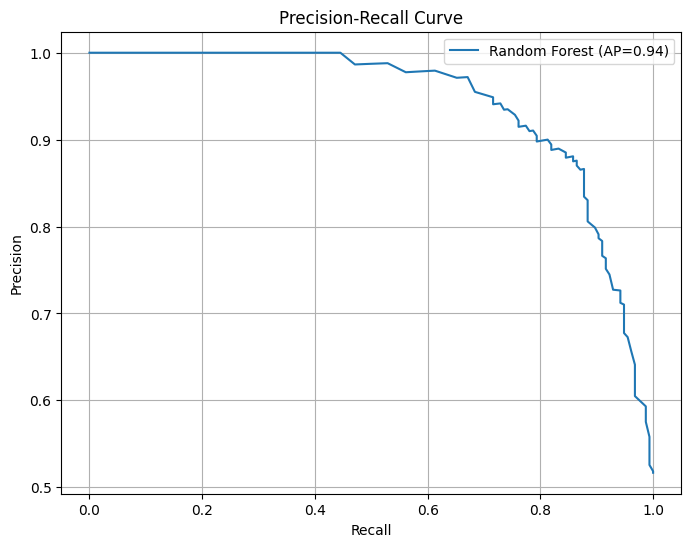

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict probabilities
y_scores = clf.predict_proba(X_test)[:, 1]

# Compute precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

# Compute average precision
avg_precision = average_precision_score(y_test, y_scores)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Random Forest (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

Q44  Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

# Define base models
rf = RandomForestClassifier(n_estimators=100, random_state=6)
lr = LogisticRegression(max_iter=200, random_state=6)

# Train individual models
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)

# Accuracy of base models
rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)

# Stacking Classifier
stacking = StackingClassifier(
    estimators=[('rf', rf), ('lr', lr)],
    final_estimator=LogisticRegression()
)
stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

# Print results
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Stacking Classifier Accuracy: {stack_acc:.4f}")

Random Forest Accuracy: 0.9333
Logistic Regression Accuracy: 0.9667
Stacking Classifier Accuracy: 0.9667


Q45  Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

Max Samples: 0.3, MSE: 0.2719, R²: 0.8030
Max Samples: 0.5, MSE: 0.2595, R²: 0.8119
Max Samples: 0.7, MSE: 0.2576, R²: 0.8133
Max Samples: 1.0, MSE: 0.2519, R²: 0.8174


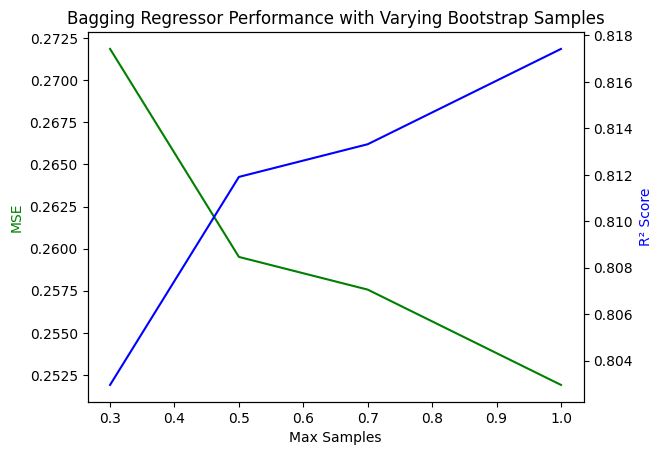

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Define different bootstrap sample sizes
bootstrap_samples = [0.3, 0.5, 0.7, 1.0]

# Store results
results = {}

for max_samples in bootstrap_samples:
    # Initialize BaggingRegressor with different bootstrap sample sizes
    bagging_regressor = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=50,  # Number of trees
        max_samples=max_samples,  # Bootstrap sample size
        random_state=5
    )

    # Train model
    bagging_regressor.fit(X_train, y_train)

    # Make predictions
    y_pred = bagging_regressor.predict(X_test)

    # Evaluate performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[max_samples] = {'MSE': mse, 'R2': r2}

    print(f"Max Samples: {max_samples}, MSE: {mse:.4f}, R²: {r2:.4f}")

# Plot performance
max_samples_list = list(results.keys())
mse_values = [results[s]['MSE'] for s in max_samples_list]
r2_values = [results[s]['R2'] for s in max_samples_list]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(max_samples_list, mse_values, 'g-')
ax2.plot(max_samples_list, r2_values, 'b-')

ax1.set_xlabel('Max Samples')
ax1.set_ylabel('MSE', color='g')
ax2.set_ylabel('R² Score', color='b')
plt.title('Bagging Regressor Performance with Varying Bootstrap Samples')
plt.show()
